<a href="https://colab.research.google.com/github/infod3-ws/FIAP_Tech_Challenge_Fase_1/blob/main/notebooks/01_EDA_NPS_Preditivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Tech Challenge — Fase 1 | NPS Preditivo
## Item 3 - Análise Exploratória de Dados (EDA)

**Curso:** Pós-Graduação em Data Science & Inteligência Artificial — FIAP PosTech  
**Fase:** 1 — Fundamentos e Análise Exploratória

---

### Contexto

Uma empresa de e-commerce em crescimento acelerado percebeu que seus indicadores operacionais pareciam razoáveis no papel, mas a experiência real do cliente contava uma história diferente revelada pela alta variabilidade no Net Promoter Score (NPS).

O NPS é coletado apenas após o encerramento da jornada de compra, o que limita a capacidade de agir de forma preventiva. Nossa missão nesta análise é entender **quais fatores operacionais realmente influenciam a satisfação do cliente** e comunicar esses achados de forma clara para quem toma decisões.

### 🧭 Pergunta Norteadora

> *"Quais fatores operacionais mais impactam a satisfação do cliente e como podemos identificar o que gera mais detratores"*

### Perguntas Adicionais

> *"Existe algum ponto de ruptura na experiência do cliente? Que tipo de cliente tende a ter um NPS mais baixo e mais alto?"*


---
## 0. Preparação do Ambiente

Antes de qualquer análise, precisamos carregar as bibliotecas que vamos usar.  
Pense nelas como as ferramentas na bancada de um técnico: cada uma tem uma função específica.


In [ ]:
# ============================================================
# BIBLIOTECAS
# pandas  → leitura e manipulação da base (como um Excel inteligente)
# numpy   → cálculos numéricos
# matplotlib / seaborn / plotly → criação dos gráficos
# warnings → silencia avisos de versão que poluem o output
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

# Estilo visual padrão para os gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Ambiente configurado com sucesso!')


✅ Ambiente configurado com sucesso!


---
## 1. Carregamento e Primeiro Olhar nos Dados

O primeiro passo em qualquer análise é entender com o que estamos trabalhando.  
Vamos carregar a base e responder as perguntas básicas: *Quantos registros temos? Quais colunas existem? Os dados estão completos?*


In [ ]:
# ============================================================
# CARREGAMENTO DA BASE
# ============================================================

df = pd.read_csv('desafio_nps_fase_1.csv')

print(f'📦 Base carregada com sucesso!')
print(f'   Registros (pedidos): {df.shape[0]:,}')
print(f'   Variáveis (colunas): {df.shape[1]}')


📦 Base carregada com sucesso!
   Registros (pedidos): 2,500
   Variáveis (colunas): 19


In [ ]:
# Overview rápido na base

df.head()


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
# Verificando tipos de dados e valores ausentes
# → Importante confirmar que números estão sendo lidos como números
#   e que não há campos vazios que possam distorcer a análise

print('--- Tipos de dados ---')
print(df.dtypes)

print('\n--- Valores ausentes por coluna ---')
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('✅ Nenhum valor ausente. Base 100% completa!')
else:
    print(nulos[nulos > 0])


--- Tipos de dados ---
customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

--- Valores ausentes por coluna ---
✅ Nenhum valor ausente. Base 100% completa!


In [ ]:
# Estatísticas descritivas das variáveis mais relevantes
# → Média, mínimo, máximo, mediana (50%) de cada coluna
# Isso nos dá uma "radiografia rápida" dos dados antes de mergulhar nas análises

cols_relevantes = [
    'customer_age', 'customer_tenure_months', 'order_value',
    'delivery_time_days', 'delivery_delay_days', 'freight_value',
    'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'nps_score'
]

df[cols_relevantes].describe().round(2)


,customer_age,customer_tenure_months,order_value,delivery_time_days,delivery_delay_days,freight_value,customer_service_contacts,resolution_time_days,complaints_count,nps_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,8.02,2.19,38.22,1.52,5.49,4.15,4.38
std,14.89,34.48,289.77,3.77,1.45,12.08,1.23,3.46,1.78,2.51
min,18.00,1.00,7.76,2.00,0.00,2.62,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,5.00,1.00,29.93,1.00,2.00,3.00,2.60
50%,43.00,62.00,375.52,8.00,2.00,38.50,1.00,6.00,4.00,4.40
75%,56.00,91.00,577.29,11.00,3.00,46.27,2.00,8.00,5.00,6.10
max,69.00,119.00,1983.81,14.00,8.00,76.13,7.00,11.00,11.00,10.00


---
## 2. Distribuição do NPS — O Diagnóstico Inicial

Antes de investigar causas, precisamos entender **como está o NPS hoje**.

O NPS é calculado assim:

$$NPS = \frac{\text{Promotores} - \text{Detratores}}{\text{Total de respondentes}} \times 100$$

As três categorias de clientes são:
- 🟢 **Promotores** → nota 9 ou 10 (leais, que indicam a empresa para outros)
- 🟡 **Neutros / Passivos** → nota 7 ou 8 (satisfeitos, mas não entusiastas)
- 🔴 **Detratores** → nota de 0 a 6 (insatisfeitos, que podem falar mal da marca)

> 💬 Imagine que pedimos para 2.500 clientes nos darem uma nota de 0 a 10. O que os números vão revelar pode ser que nossa situação é mais grave do que os indicadores operacionais sugerem ou não.


In [ ]:
# ============================================================
# CRIANDO A VARIÁVEL DE CATEGORIA NPS
# Transformamos a nota numérica (0–10) em 3 categorias de negócio
# ============================================================

def categorizar_nps(nota):
    if nota >= 9:
        return 'Promotor'
    elif nota >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df['nps_categoria'] = df['nps_score'].apply(categorizar_nps)

# Contagens e percentuais
total = len(df)
contagem   = df['nps_categoria'].value_counts()
percentual = df['nps_categoria'].value_counts(normalize=True).mul(100).round(1)

# NPS consolidado (fórmula oficial)
promotores = contagem.get('Promotor', 0)
detratores = contagem.get('Detrator', 0)
nps_consolidado = round(((promotores - detratores) / total) * 100, 1)

print('=' * 48)
print(f'   NPS CONSOLIDADO DA EMPRESA: {nps_consolidado} pontos')
print('=' * 48)
print(f'  🔴 Detratores : {contagem["Detrator"]:,} clientes ({percentual["Detrator"]}%)')
print(f'  🟡 Neutros    : {contagem["Neutro"]:,} clientes ({percentual["Neutro"]}%)')
print(f'  🟢 Promotores : {contagem["Promotor"]:,} clientes ({percentual["Promotor"]}%)')
print('=' * 48)


   NPS CONSOLIDADO DA EMPRESA: -80.0 pontos
  🔴 Detratores : 2,109 clientes (84.4%)
  🟡 Neutros    : 281 clientes (11.2%)
  🟢 Promotores : 110 clientes (4.4%)


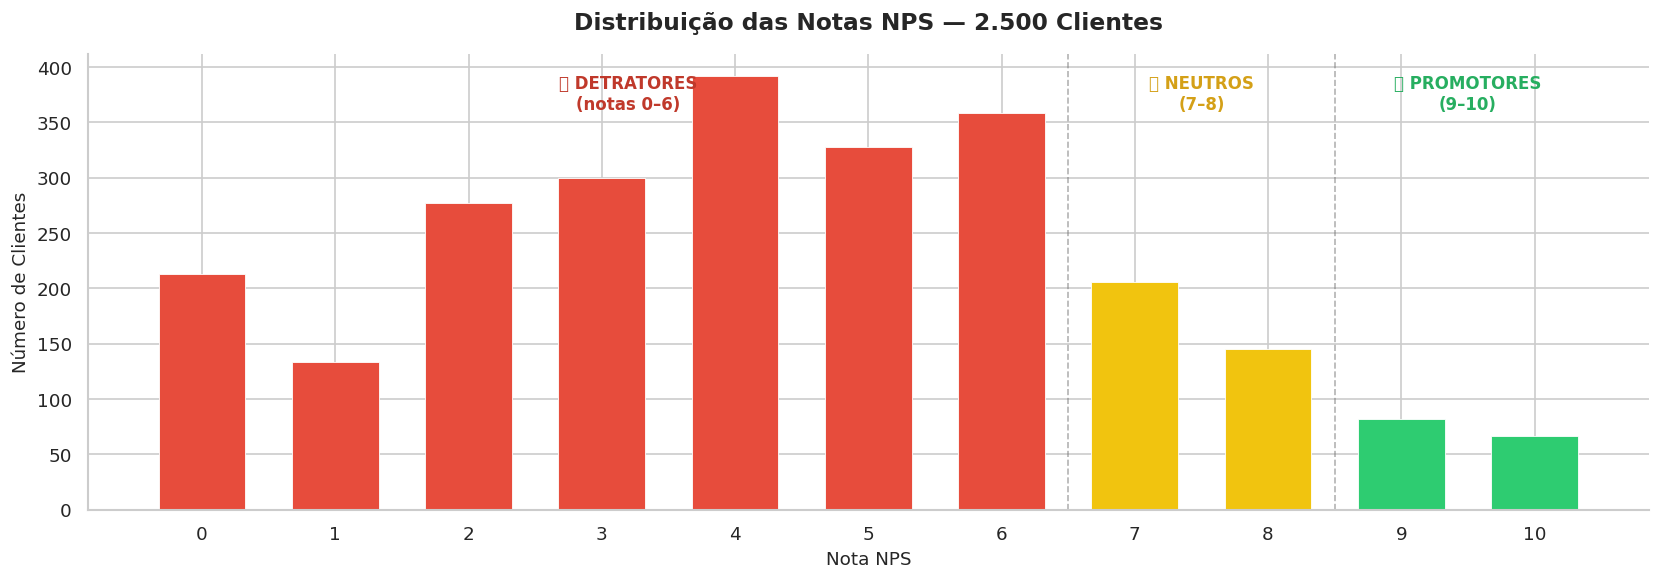

A grande maioria das notas está concentrada entre 0 e 6 (zona vermelha).
84% dos clientes estão insatisfeitos. Apenas 4,4% nos indicariam para alguém.


In [ ]:
# ============================================================
# GRÁFICO 1 — Histograma das notas NPS (0 a 10)
# Mostra quantos clientes deram cada nota
# Cores indicam a zona: vermelho = detrator, amarelo = neutro, verde = promotor
# ============================================================

def cor_nota(nota):
    if nota >= 9:   return '#2ecc71'   # verde
    elif nota >= 7: return '#f1c40f'   # amarelo
    else:           return '#e74c3c'   # vermelho

dist_notas = (
    df['nps_score']
    .round(0)
    .value_counts()
    .sort_index()
    .reset_index()
)
dist_notas.columns = ['nota', 'qtd']
dist_notas['cor'] = dist_notas['nota'].apply(cor_nota)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(dist_notas['nota'], dist_notas['qtd'],
       color=dist_notas['cor'], edgecolor='white', linewidth=0.5, width=0.65)

# Linhas divisórias entre zonas
ax.axvline(x=6.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(x=8.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Rótulos das zonas
ax.text(3.2, ax.get_ylim()[1] * 0.88, '🔴 DETRATORES\n(notas 0–6)',
        ha='center', fontsize=10, color='#c0392b', fontweight='bold')
ax.text(7.5, ax.get_ylim()[1] * 0.88, '🟡 NEUTROS\n(7–8)',
        ha='center', fontsize=10, color='#d4a017', fontweight='bold')
ax.text(9.5, ax.get_ylim()[1] * 0.88, '🟢 PROMOTORES\n(9–10)',
        ha='center', fontsize=10, color='#27ae60', fontweight='bold')

ax.set_title('Distribuição das Notas NPS — 2.500 Clientes', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nota NPS', fontsize=11)
ax.set_ylabel('Número de Clientes', fontsize=11)
ax.set_xticks(range(0, 11))
sns.despine()
plt.tight_layout()
plt.show()

print('A grande maioria das notas está concentrada entre 0 e 6 (zona vermelha).')
print('84% dos clientes estão insatisfeitos. Apenas 4,4% nos indicariam para alguém.')


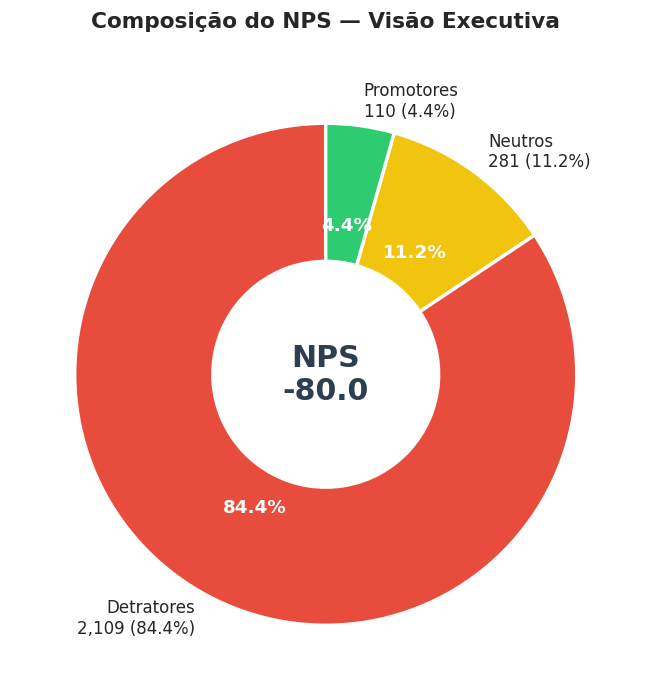

NPS -80.0 pontos. Referência: líderes de e-commerce operam entre +40 e +70.
Temos quase 20 detratores para cada promotor.


In [ ]:
# ============================================================
# GRÁFICO 2 — Composição do NPS em formato donut
# Visão rápida e executiva das três categorias
# ============================================================

categorias_ordem = ['Detrator', 'Neutro', 'Promotor']
valores = [contagem[c] for c in categorias_ordem]
cores   = ['#e74c3c', '#f1c40f', '#2ecc71']
labels  = [
    f'Detratores\n{contagem["Detrator"]:,} ({percentual["Detrator"]}%)',
    f'Neutros\n{contagem["Neutro"]:,} ({percentual["Neutro"]}%)',
    f'Promotores\n{contagem["Promotor"]:,} ({percentual["Promotor"]}%)'
]

fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, autotexts = ax.pie(
    valores,
    labels=labels,
    colors=cores,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

# NPS consolidado no centro do donut
ax.text(0, 0, f'NPS\n{nps_consolidado}', ha='center', va='center',
        fontsize=18, fontweight='bold', color='#2c3e50')

ax.set_title('Composição do NPS — Visão Executiva', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f'NPS {nps_consolidado} pontos. Referência: líderes de e-commerce operam entre +40 e +70.')
print('Temos quase 20 detratores para cada promotor.')



---
## 3. O Que Mais Impacta o NPS? — Ranking de Correlações

Agora a pergunta central: **o que está causando tanta insatisfação?**

Medimos a **correlação** entre cada variável operacional e o NPS.

> 💬 A correlação mostra o quanto duas coisas "andam juntas". Se a correlação entre atraso e NPS for negativa e alta, significa que quanto mais dias de atraso, menor a nota e isso acontece de forma consistente, não é coincidência.

**Como ler o gráfico:**
- Barras **vermelhas** (para a esquerda) → fator que **derruba** o NPS
- Barras **verdes** (para a direita) → fator que **eleva** o NPS
- Quanto mais longa a barra, mais forte o efeito

> ⚠️ **Nota técnica:** excluímos `repeat_purchase_30d` e `csat_internal_score` desta análise. Ambas são *consequências* da satisfação, não causas. Incluí-las seria como tentar prever o resultado de um jogo usando a tabela de classificação final como pista.


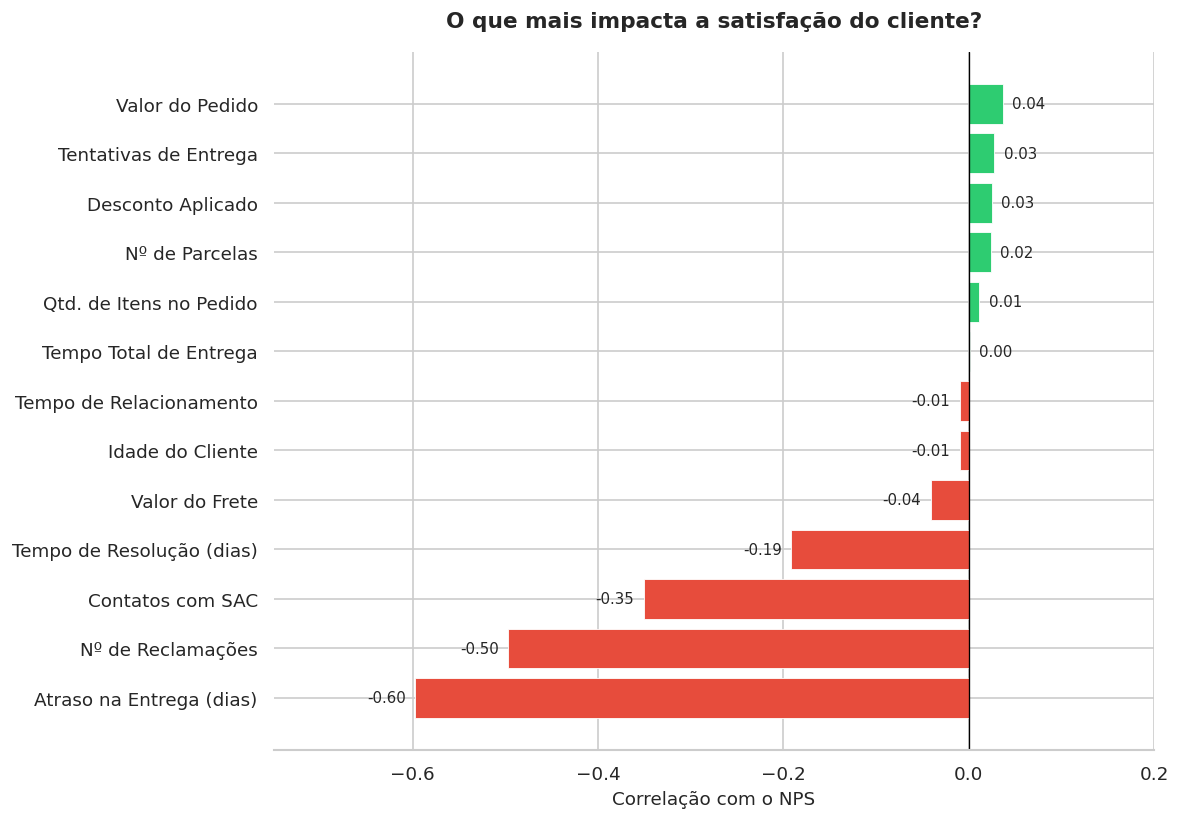

In [ ]:
# ============================================================
# CORRELAÇÃO DAS VARIÁVEIS OPERACIONAIS COM O NPS
# Excluímos variáveis que são consequência do NPS (data leakage):
#   repeat_purchase_30d → se o cliente voltou é resultado da satisfação
#   csat_internal_score → outra métrica de satisfação, coletada em paralelo
# ============================================================

features_operacionais = [
    'delivery_delay_days', 'complaints_count', 'customer_service_contacts',
    'resolution_time_days', 'freight_value', 'customer_age',
    'customer_tenure_months', 'delivery_time_days', 'items_quantity',
    'payment_installments', 'discount_value', 'delivery_attempts', 'order_value'
]

correlacoes = (
    df[features_operacionais + ['nps_score']]
    .corr()['nps_score']
    .drop('nps_score')
    .sort_values()
)

nomes_legíveis = {
    'delivery_delay_days'       : 'Atraso na Entrega (dias)',
    'complaints_count'          : 'Nº de Reclamações',
    'customer_service_contacts' : 'Contatos com SAC',
    'resolution_time_days'      : 'Tempo de Resolução (dias)',
    'freight_value'             : 'Valor do Frete',
    'customer_age'              : 'Idade do Cliente',
    'customer_tenure_months'    : 'Tempo de Relacionamento',
    'delivery_time_days'        : 'Tempo Total de Entrega',
    'items_quantity'            : 'Qtd. de Itens no Pedido',
    'payment_installments'      : 'Nº de Parcelas',
    'discount_value'            : 'Desconto Aplicado',
    'delivery_attempts'         : 'Tentativas de Entrega',
    'order_value'               : 'Valor do Pedido'
}

labels_grafico = [nomes_legíveis.get(i, i) for i in correlacoes.index]
cores_barras   = ['#e74c3c' if v < 0 else '#2ecc71' for v in correlacoes.values]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(labels_grafico, correlacoes.values,
               color=cores_barras, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, correlacoes.values):
    offset = 0.01 if val >= 0 else -0.01
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação com o NPS', fontsize=11)
ax.set_title('O que mais impacta a satisfação do cliente?', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(-0.75, 0.20)
sns.despine(left=True)
plt.tight_layout()
plt.show()


---
## 4. Fator 1 — Atraso na Entrega: o Maior Destruidor de NPS

O atraso na entrega tem a correlação mais forte com o NPS (−0,60). Mas mais importante do que o número é entender **como** a satisfação despenca conforme os dias passam.

> 💬 Pense na paciência do cliente como uma barragem. Um dia de atraso é como uma goteira, um incômodo, mas suportável. A partir do 3º dia, a pressão aumenta tanto que a estrutura começa a ceder. Aos 7 dias, ela já rompeu completamente.

**Uma descoberta contraintuitiva dos dados:**
- `delivery_time_days` (tempo total de entrega) → correlação de **0,0009** com NPS → irrelevante
- `delivery_delay_days` (dias de atraso) → correlação de **−0,60** com NPS → fortíssima

O cliente **não mede o tempo da entrega**, ele mede se a empresa **cumpriu a promessa**.  
Uma entrega que demora 14 dias, mas chega no prazo combinado, não destroi o NPS.


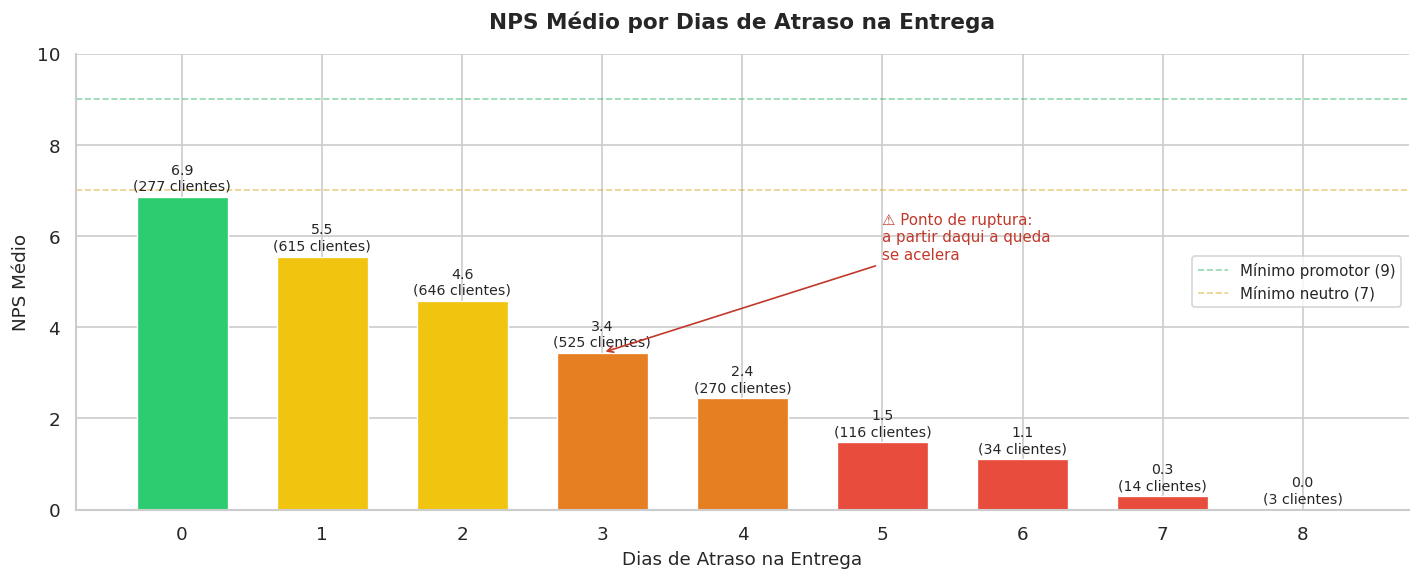

Sem atraso → NPS médio de 6,9 (ainda ruim, mas muito melhor que o restante)
3 dias de atraso → NPS cai para 3,4 — o ponto onde a insatisfação acelera
7 dias de atraso → NPS chega a 0,3. Praticamente zero.
A cada dia extra de atraso, estamos criando detratores ativos.


In [ ]:
# ============================================================
# NPS MÉDIO POR DIA DE ATRASO
# Agrupamos os clientes pelo número de dias de atraso
# e calculamos a nota média de NPS em cada grupo
# ============================================================

nps_atraso = (
    df.groupby('delivery_delay_days')['nps_score']
    .agg(nps_medio='mean', clientes='count')
    .reset_index()
    .round(2)
)

def cor_atraso(dias):
    if dias == 0:   return '#2ecc71'
    elif dias <= 2: return '#f1c40f'
    elif dias <= 4: return '#e67e22'
    else:           return '#e74c3c'

nps_atraso['cor'] = nps_atraso['delivery_delay_days'].apply(cor_atraso)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    nps_atraso['delivery_delay_days'],
    nps_atraso['nps_medio'],
    color=nps_atraso['cor'],
    edgecolor='white', linewidth=0.8, width=0.65
)

# Rótulo: NPS médio + quantidade de clientes
for bar, row in zip(bars, nps_atraso.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            f'{row.nps_medio:.1f}\n({row.clientes} clientes)',
            ha='center', va='bottom', fontsize=8.5)

# Linha de referência: limiar do promotor (nota 9)
ax.axhline(y=9, color='#27ae60', linestyle='--', linewidth=1, alpha=0.5, label='Mínimo promotor (9)')
ax.axhline(y=7, color='#d4a017', linestyle='--', linewidth=1, alpha=0.5, label='Mínimo neutro (7)')

# Anotação do ponto de ruptura
ax.annotate('⚠️ Ponto de ruptura:\na partir daqui a queda\nse acelera',
            xy=(3, 3.44), xytext=(5, 5.5),
            arrowprops=dict(arrowstyle='->', color='#c0392b'),
            fontsize=9, color='#c0392b')

ax.set_title('NPS Médio por Dias de Atraso na Entrega', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Dias de Atraso na Entrega', fontsize=11)
ax.set_ylabel('NPS Médio', fontsize=11)
ax.set_xticks(nps_atraso['delivery_delay_days'])
ax.set_ylim(0, 10)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print('Sem atraso → NPS médio de 6,9 (ainda ruim, mas muito melhor que o restante)')
print('3 dias de atraso → NPS cai para 3,4 — o ponto onde a insatisfação acelera')
print('7 dias de atraso → NPS chega a 0,3. Praticamente zero.')
print('A cada dia extra de atraso, estamos criando detratores ativos.')


---
## 5. Fator 2 — Acúmulo de Reclamações

O número de reclamações registradas tem a segunda maior correlação com o NPS (−0,50).

> 💬 Um erro pontual não necessariamente destrói a relação com o cliente. O que destrói é o acúmulo. Um cliente que passou por 5, 6, 7 problemas ao longo da jornada está sendo sistematicamente frustrado, quando chega a pesquisa de NPS, já decidiu a nota muito antes de respondê-la.


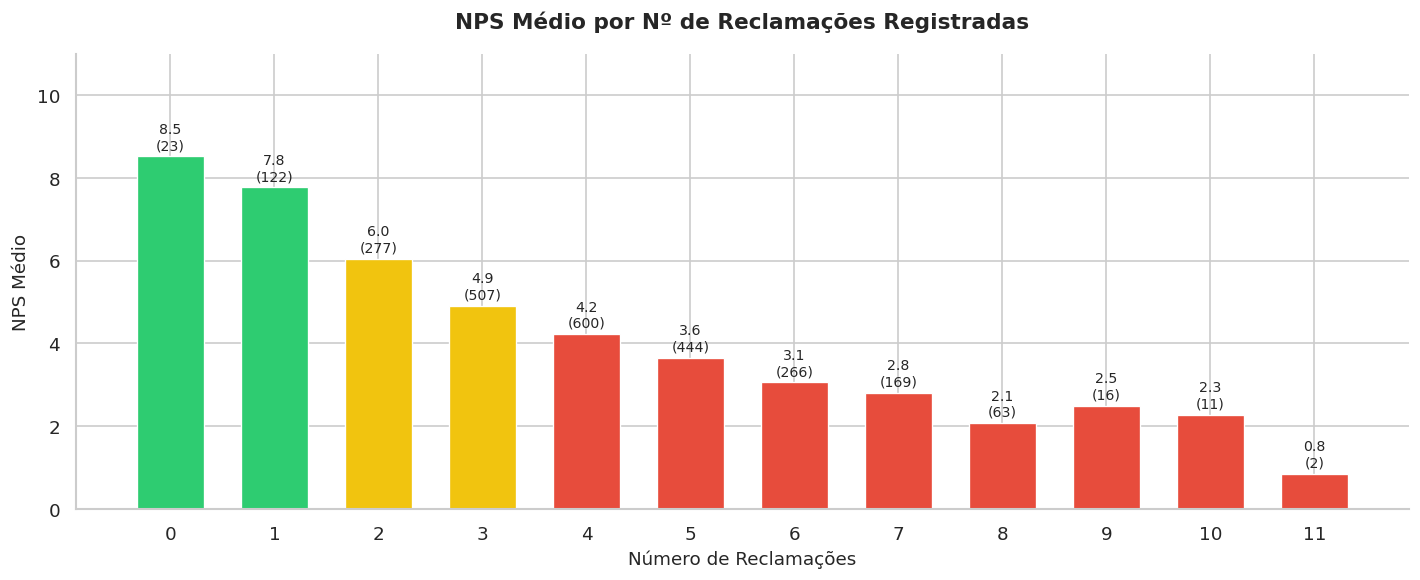

0 reclamações → NPS médio de 8,5 (patamar de neutro/promotor)
3 reclamações → NPS cai para 4,9
7 ou mais reclamações → NPS abaixo de 3. Detrator praticamente garantido.
A boa notícia: quem chega com zero reclamações quase vira promotor.


In [ ]:
# ============================================================
# NPS MÉDIO POR NÚMERO DE RECLAMAÇÕES
# ============================================================

nps_reclamacoes = (
    df.groupby('complaints_count')['nps_score']
    .agg(nps_medio='mean', clientes='count')
    .reset_index()
    .round(2)
)

fig, ax = plt.subplots(figsize=(12, 5))

cores_rec = ['#2ecc71' if r <= 1 else '#f1c40f' if r <= 3 else '#e74c3c'
             for r in nps_reclamacoes['complaints_count']]

bars = ax.bar(
    nps_reclamacoes['complaints_count'],
    nps_reclamacoes['nps_medio'],
    color=cores_rec, edgecolor='white', linewidth=0.8, width=0.65
)

for bar, row in zip(bars, nps_reclamacoes.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{row.nps_medio:.1f}\n({row.clientes})',
            ha='center', va='bottom', fontsize=8.5)

ax.set_title('NPS Médio por Nº de Reclamações Registradas', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Número de Reclamações', fontsize=11)
ax.set_ylabel('NPS Médio', fontsize=11)
ax.set_xticks(nps_reclamacoes['complaints_count'])
ax.set_ylim(0, 11)
sns.despine()
plt.tight_layout()
plt.show()

print('0 reclamações → NPS médio de 8,5 (patamar de neutro/promotor)')
print('3 reclamações → NPS cai para 4,9')
print('7 ou mais reclamações → NPS abaixo de 3. Detrator praticamente garantido.')
print('A boa notícia: quem chega com zero reclamações quase vira promotor.')


---
## 6. Fator 3 — Contatos com o SAC: quando o Suporte Amplifica a Frustração

O número de contatos com o atendimento tem correlação de −0,35 com o NPS.

> 💬 O SAC deveria ser a rede de salvação, o momento em que a empresa recupera a confiança do cliente após um problema. Mas os dados mostram que cada contato adicional está piorando o NPS. Isso sugere que os problemas **não estão sendo resolvidos na primeira ligação**. O cliente liga, não resolve, liga de novo, fica mais frustrado, e quando a pesquisa chega, descarrega tudo na nota.


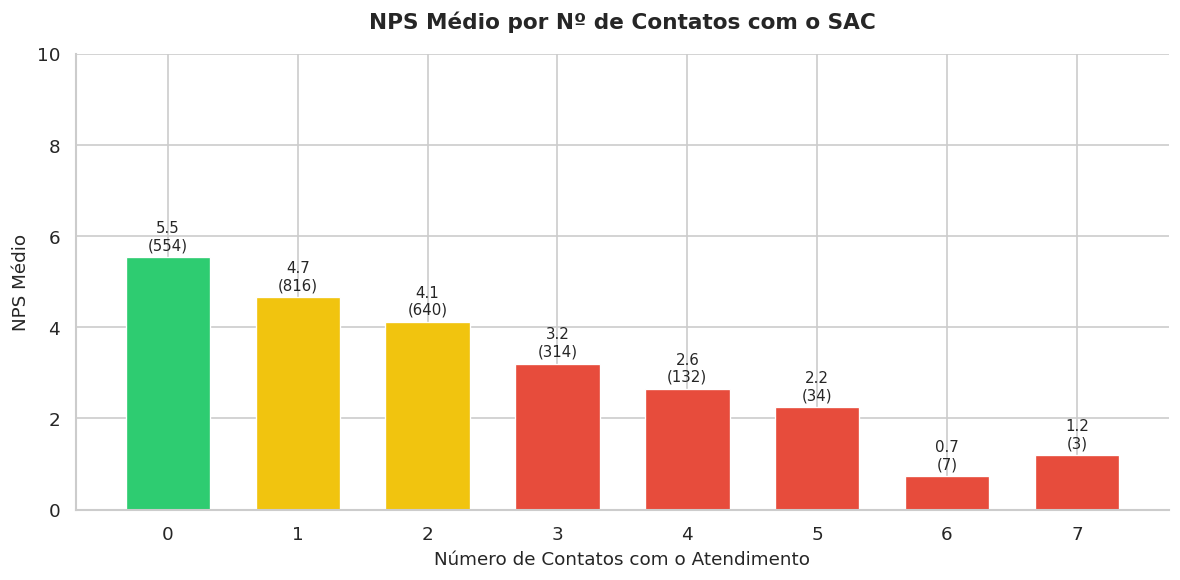

0 contatos com SAC → NPS médio de 5,5
3 contatos          → cai para 3,2
6 contatos          → chega a 0,7. Quase zero.
Cada vez que o cliente precisa ligar de novo, perdemos mais um pedaço da satisfação.


In [ ]:
# ============================================================
# NPS MÉDIO POR NÚMERO DE CONTATOS COM O SAC
# ============================================================

nps_sac = (
    df.groupby('customer_service_contacts')['nps_score']
    .agg(nps_medio='mean', clientes='count')
    .reset_index()
    .round(2)
)

fig, ax = plt.subplots(figsize=(10, 5))

cores_sac = ['#2ecc71' if c == 0 else '#f1c40f' if c <= 2 else '#e74c3c'
             for c in nps_sac['customer_service_contacts']]

bars = ax.bar(
    nps_sac['customer_service_contacts'],
    nps_sac['nps_medio'],
    color=cores_sac, edgecolor='white', linewidth=0.8, width=0.65
)

for bar, row in zip(bars, nps_sac.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{row.nps_medio:.1f}\n({row.clientes})',
            ha='center', va='bottom', fontsize=9)

ax.set_title('NPS Médio por Nº de Contatos com o SAC', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Número de Contatos com o Atendimento', fontsize=11)
ax.set_ylabel('NPS Médio', fontsize=11)
ax.set_xticks(nps_sac['customer_service_contacts'])
ax.set_ylim(0, 10)
sns.despine()
plt.tight_layout()
plt.show()

print('0 contatos com SAC → NPS médio de 5,5')
print('3 contatos          → cai para 3,2')
print('6 contatos          → chega a 0,7. Quase zero.')
print('Cada vez que o cliente precisa ligar de novo, perdemos mais um pedaço da satisfação.')


---
## 7. A Combinação Mais Destrutiva: Atraso + SAC Repetido

Individualmente, atraso e múltiplos contatos com SAC já são ruins.  
Juntos, eles formam o cenário mais destrutivo que os dados revelam.

> 💬 Um cliente que esperou 5 dias além do prazo e ainda precisou ligar para o SAC 3 vezes sem ter o problema resolvido, gera uma catástrofe. Esse cliente não está apenas insatisfeito, ele está com raiva. E um cliente com raiva faz questão de contar para alguém.


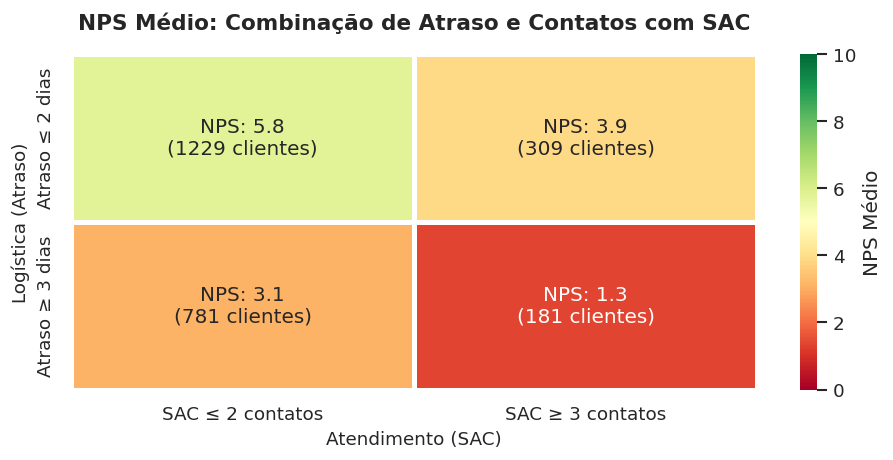

🟢 Sem atraso + poucos contatos (o melhor que temos)
🟡 Sem atraso + SAC repetido    (SAC já prejudica sozinho)
🟠 Atraso alto + pouco SAC      (entrega ruim, mesmo sem ligar)
🔴 Atraso alto + SAC repetido   (o pior cenário possível)

Esses 181 clientes com NPS 1,3 são detratores ativos.
Alta chance de avaliação negativa pública e zero probabilidade de recompra.


In [ ]:
# ============================================================
# COMBINAÇÃO: ATRASO ALTO (≥3 dias) + SAC ALTO (≥3 contatos)
# Criamos duas variáveis binárias e calculamos o NPS médio
# em cada combinação possível
# ============================================================

df['atraso_alto'] = df['delivery_delay_days'] >= 3
df['sac_alto']    = df['customer_service_contacts'] >= 3

combo = (
    df.groupby(['atraso_alto', 'sac_alto'])['nps_score']
    .agg(nps_medio='mean', clientes='count')
    .reset_index()
    .round(2)
)

# Montar tabela pivot para o heatmap
pivot_nps = combo.pivot(index='atraso_alto', columns='sac_alto', values='nps_medio')
pivot_nps.index   = ['Atraso ≤ 2 dias', 'Atraso ≥ 3 dias']
pivot_nps.columns = ['SAC ≤ 2 contatos', 'SAC ≥ 3 contatos']

pivot_qtd = combo.pivot(index='atraso_alto', columns='sac_alto', values='clientes')
pivot_qtd.index   = ['Atraso ≤ 2 dias', 'Atraso ≥ 3 dias']
pivot_qtd.columns = ['SAC ≤ 2 contatos', 'SAC ≥ 3 contatos']

# Anotações com NPS + qtd de clientes
anotacoes = pivot_nps.copy().astype(str)
for i in pivot_nps.index:
    for j in pivot_nps.columns:
        nps_val = pivot_nps.loc[i, j]
        qtd_val = pivot_qtd.loc[i, j]
        anotacoes.loc[i, j] = f'NPS: {nps_val:.1f}\n({qtd_val} clientes)'

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    pivot_nps,
    annot=anotacoes,
    fmt='',
    cmap='RdYlGn',
    vmin=0, vmax=10,
    linewidths=2,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'NPS Médio'}
)

ax.set_title('NPS Médio: Combinação de Atraso e Contatos com SAC',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Atendimento (SAC)', fontsize=11)
ax.set_ylabel('Logística (Atraso)', fontsize=11)
plt.tight_layout()
plt.show()

print('🟢 Sem atraso + poucos contatos (o melhor que temos)')
print('🟡 Sem atraso + SAC repetido    (SAC já prejudica sozinho)')
print('🟠 Atraso alto + pouco SAC      (entrega ruim, mesmo sem ligar)')
print('🔴 Atraso alto + SAC repetido   (o pior cenário possível)')
print('\nEsses 181 clientes com NPS 1,3 são detratores ativos.')
print('Alta chance de avaliação negativa pública e zero probabilidade de recompra.')


---
## 8. O Que NÃO Impacta o NPS — As Surpresas dos Dados

Tão importante quanto saber o que afeta a satisfação é entender o que **não afeta**.  
Isso evita que a empresa invista em ações que não vão mudar o resultado.


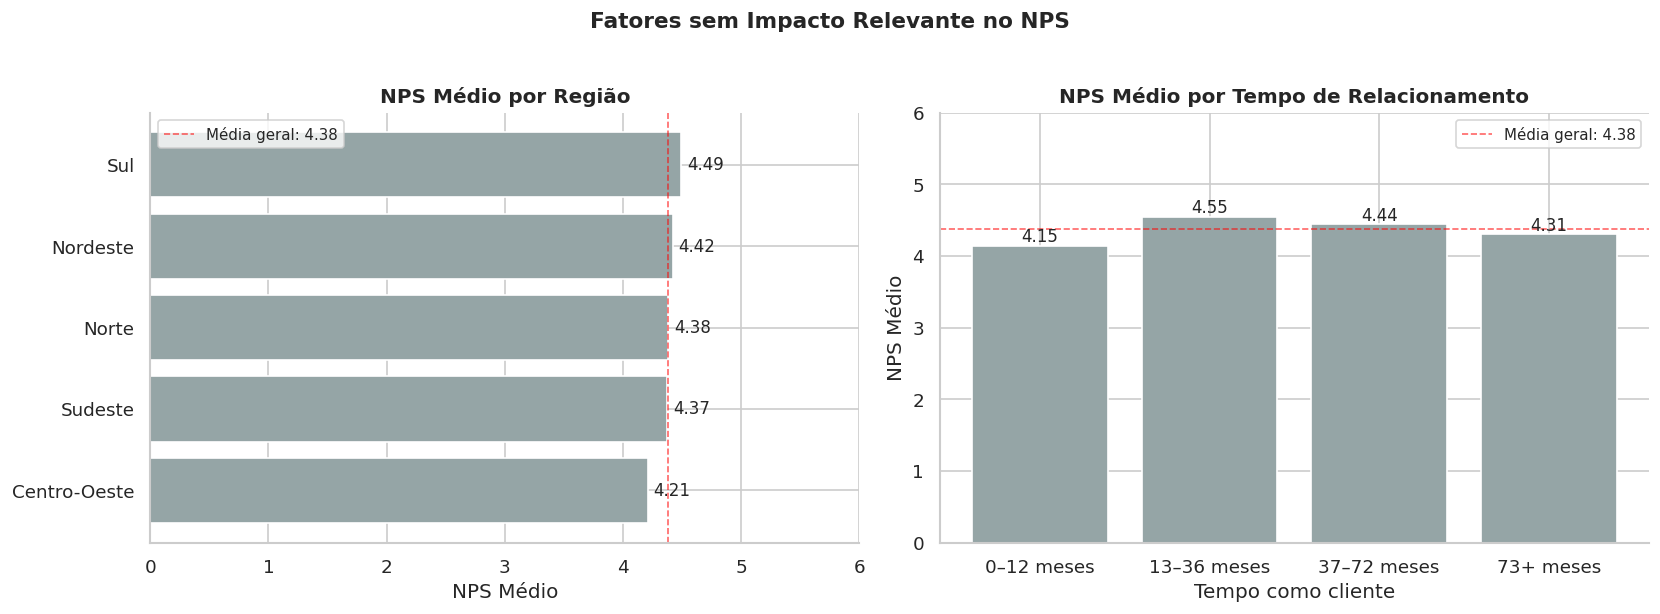

Região: a diferença entre a melhor (Sul, 4,49) e a pior (Centro-Oeste, 4,21) é de apenas 0,28 pontos.
→ O problema NÃO é geográfico. Todas as regiões estão igualmente insatisfeitas.

Tempo de relacionamento: clientes de 1 mês e de 10 anos têm NPS praticamente idêntico.
→ A lealdade histórica não protege o cliente de uma experiência ruim no presente.
→ Investir em programas de fidelidade sem resolver entrega e SAC não vai funcionar.


In [ ]:
# ============================================================
# VARIÁVEIS SEM IMPACTO RELEVANTE NO NPS
# Região geográfica e tempo de relacionamento
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico A: NPS por Região ---
nps_regiao = (
    df.groupby('customer_region')['nps_score']
    .mean()
    .sort_values()
    .reset_index()
)

axes[0].barh(nps_regiao['customer_region'], nps_regiao['nps_score'],
             color='#95a5a6', edgecolor='white')

for i, row in nps_regiao.iterrows():
    axes[0].text(row['nps_score'] + 0.05, i,
                 f'{row["nps_score"]:.2f}', va='center', fontsize=10)

axes[0].set_xlim(0, 6)
axes[0].set_title('NPS Médio por Região', fontsize=12, fontweight='bold')
axes[0].set_xlabel('NPS Médio')
axes[0].axvline(x=df['nps_score'].mean(), color='red',
                linestyle='--', linewidth=1, alpha=0.6, label=f'Média geral: {df["nps_score"].mean():.2f}')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# --- Gráfico B: NPS por faixa de tempo de relacionamento ---
df['tenure_faixa'] = pd.cut(
    df['customer_tenure_months'],
    bins=[0, 12, 36, 72, 119],
    labels=['0–12 meses', '13–36 meses', '37–72 meses', '73+ meses']
)

nps_tenure = (
    df.groupby('tenure_faixa', observed=True)['nps_score']
    .mean()
    .reset_index()
)

axes[1].bar(nps_tenure['tenure_faixa'], nps_tenure['nps_score'],
            color='#95a5a6', edgecolor='white')

for i, row in nps_tenure.iterrows():
    axes[1].text(i, row['nps_score'] + 0.05,
                 f'{row["nps_score"]:.2f}', ha='center', fontsize=10)

axes[1].set_ylim(0, 6)
axes[1].set_title('NPS Médio por Tempo de Relacionamento', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tempo como cliente')
axes[1].set_ylabel('NPS Médio')
axes[1].axhline(y=df['nps_score'].mean(), color='red',
                linestyle='--', linewidth=1, alpha=0.6, label=f'Média geral: {df["nps_score"].mean():.2f}')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.suptitle('Fatores sem Impacto Relevante no NPS', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Região: a diferença entre a melhor (Sul, 4,49) e a pior (Centro-Oeste, 4,21) é de apenas 0,28 pontos.')
print('→ O problema NÃO é geográfico. Todas as regiões estão igualmente insatisfeitas.')
print('\nTempo de relacionamento: clientes de 1 mês e de 10 anos têm NPS praticamente idêntico.')
print('→ A lealdade histórica não protege o cliente de uma experiência ruim no presente.')
print('→ Investir em programas de fidelidade sem resolver entrega e SAC não vai funcionar.')


---
## 9. Perfil do Detrator vs. Perfil do Promotor

Com os fatores identificados, podemos agora traçar o **perfil típico** de cada tipo de cliente.  
Isso é o que permite criar ações preventivas e personalizadas.

> 💬 De um lado, o cliente que saiu satisfeito e vai nos recomendar. Do outro, o que saiu insatisfeito e provavelmente vai reclamar em algum lugar. O que os diferencia não é sorte, são variáveis operacionais que controlamos.


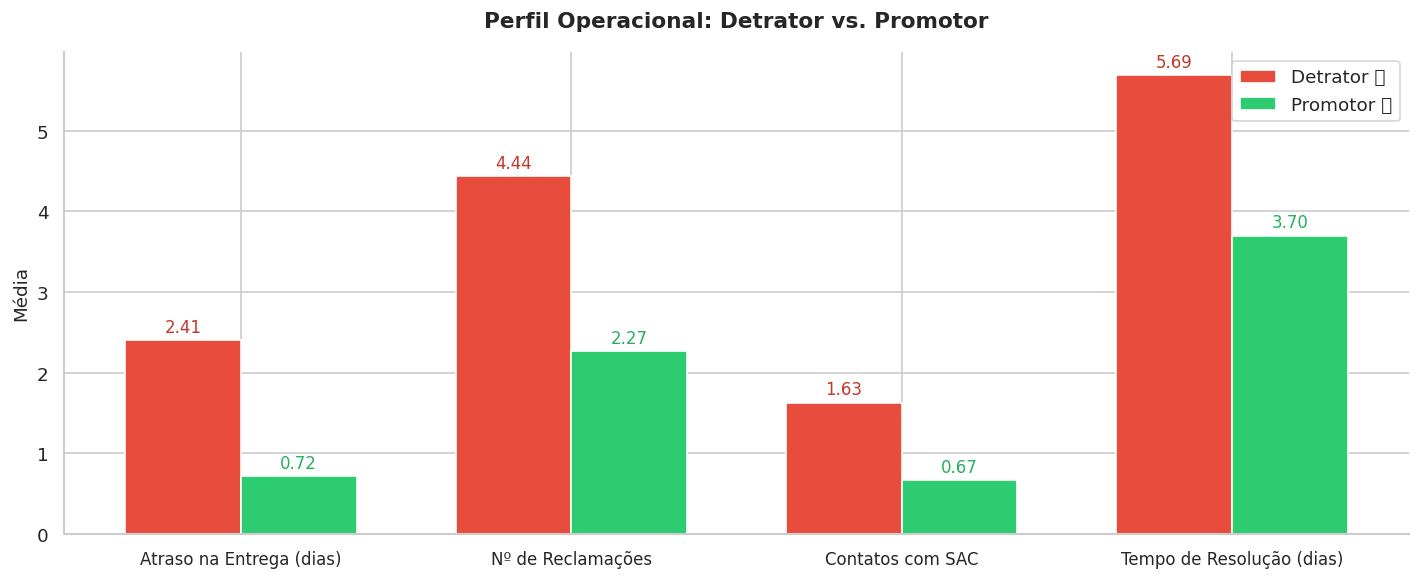


📊 Tabela resumo:
                           Detrator 🔴  Promotor 🟢
Atraso na Entrega (dias)         2.41        0.72
Nº de Reclamações                4.44        2.27
Contatos com SAC                 1.63        0.67
Tempo de Resolução (dias)        5.69        3.70
O promotor típico: chegou com 0,7 dia de atraso, 2,3 reclamações, 0,7 contatos com SAC.
O detrator típico: 2,4 dias de atraso, 4,4 reclamações, 1,6 contatos com SAC.
A diferença não é aleatória — é operacional, e está ao nosso alcance mudar.


In [ ]:
# ============================================================
# COMPARAÇÃO DE PERFIL: DETRATOR vs PROMOTOR
# Médias das principais variáveis operacionais por categoria
# ============================================================

variaveis_perfil = {
    'delivery_delay_days'       : 'Atraso na Entrega (dias)',
    'complaints_count'          : 'Nº de Reclamações',
    'customer_service_contacts' : 'Contatos com SAC',
    'resolution_time_days'      : 'Tempo de Resolução (dias)'
}

det  = df[df['nps_categoria'] == 'Detrator']
prom = df[df['nps_categoria'] == 'Promotor']

medias_det  = det[list(variaveis_perfil.keys())].mean().round(2)
medias_prom = prom[list(variaveis_perfil.keys())].mean().round(2)

perfil = pd.DataFrame({
    'Detrator 🔴' : medias_det,
    'Promotor 🟢' : medias_prom
})
perfil.index = list(variaveis_perfil.values())

x = range(len(perfil))
largura = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar([i - largura/2 for i in x], perfil['Detrator 🔴'],
               width=largura, label='Detrator 🔴', color='#e74c3c', edgecolor='white')
bars2 = ax.bar([i + largura/2 for i in x], perfil['Promotor 🟢'],
               width=largura, label='Promotor 🟢', color='#2ecc71', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, color='#c0392b')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, color='#27ae60')

ax.set_xticks(list(x))
ax.set_xticklabels(perfil.index, fontsize=10)
ax.set_ylabel('Média', fontsize=11)
ax.set_title('Perfil Operacional: Detrator vs. Promotor', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

print('\n📊 Tabela resumo:')
print(perfil.to_string())

print('O promotor típico: chegou com 0,7 dia de atraso, 2,3 reclamações, 0,7 contatos com SAC.')
print('O detrator típico: 2,4 dias de atraso, 4,4 reclamações, 1,6 contatos com SAC.')
print('A diferença não é aleatória — é operacional, e está ao nosso alcance mudar.')


---
## 10. Conclusão Executiva — O Que os Dados Nos Dizem

### 🔴 A Situação

Nosso NPS consolidado é **−80 pontos**. 84% dos clientes que responderam são detratores.  
Isso não é uma variabilidade estatística, é um problema estrutural de experiência do cliente.

---

### 🎯 Os Três Fatores que Controlam o NPS

| Fator | Correlação | Mensagem prática |
|---|---|---|
| **Atraso na entrega** | −0,60 | A partir do 3º dia, a queda do NPS se acelera drasticamente |
| **Acúmulo de reclamações** | −0,50 | Clientes com 0 reclamações quase viram promotores |
| **Contatos com o SAC** | −0,35 | Cada nova ligação indica um problema não resolvido |

---

### ⚠️ Atenção: o que NÃO causa o problema

- **Região geográfica** → todas as regiões têm NPS praticamente igual
- **Tempo de relacionamento** → clientes antigos não são mais tolerantes
- **Valor do pedido** → gastar mais ou menos não define satisfação
- **Tempo total de entrega** → o que importa é cumprir o prazo prometido, não ser rápido

---

### 🚀 Próximo Passo

Com esses fatores mapeados, é possível construir um **modelo preditivo** que identifique, ainda durante a jornada de compra, quais clientes estão em risco de se tornarem detratores, antes mesmo de a pesquisa ser enviada.

Isso transforma a análise de um olhar para o passado em uma **ferramenta de ação preventiva**.
